<a href="https://colab.research.google.com/github/Alancin321/Introducci-n-a-SI/blob/main/ProyectoFinal_ISI1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import csv
from datetime import datetime
from typing import List, Dict, Optional

# ==========================================
# CAPA DE DOMINIO: ENTIDADES DEL NEGOCIO
# ==========================================

class Producto:
    """
    Clase que representa un ítem del menú (Equivalente a una entidad del SCM).
    En Java esto sería una clase con atributos privados y getters/setters públicas.
    """
    def __init__(self, nombre: str, categoria: str, precio: float):
        # 'self' actúa exactamente como 'this' en Java
        self._nombre: str = nombre
        self._categoria: str = categoria
        self._precio: float = precio
        # Stock teórico inicial fijado para simulación logística
        self._stock_teorico: int = 100

    @property
    def nombre(self) -> str:
        """Método Getter para el nombre del producto."""
        return self._nombre

    @property
    def categoria(self) -> str:
        return self._categoria

    @property
    def precio(self) -> float:
        return self._precio

    @property
    def stock_teorico(self) -> int:
        return self._stock_teorico

    def descontar_stock(self, cantidad: int) -> bool:
        """
        Reduce el inventario teórico tras una venta.
        Retorna True si la operación fue exitosa, False si no hay stock suficiente.
        """
        if self._stock_teorico >= cantidad:
            self._stock_teorico -= cantidad
            return True
        return False

    def __repr__(self) -> str:
        # Equivalente al método toString() en Java
        return f"Producto(nombre='{self._nombre}', precio={self._precio}, stock={self._stock_teorico})"

In [ ]:
class Cliente:
    """
    Clase que modela al consumidor (Base para la gestión CRM).
    """
    def __init__(self, nombre: str):
        self._nombre: str = nombre
        self._frecuencia_compras: int = 0
        self._gasto_total: float = 0.0
        self._ultima_compra: Optional[datetime] = None

    @property
    def nombre(self) -> str:
        return self._nombre

    @property
    def gasto_total(self) -> float:
        return self._gasto_total

    @property
    def frecuencia_compras(self) -> int:
        return self._frecuencia_compras

    def registrar_interaccion(self, monto: float, fecha: datetime) -> None:
        """Actualiza el historial transaccional del cliente."""
        self._frecuencia_compras += 1
        self._gasto_total += monto
        # Si es la primera compra o es una compra más reciente, actualizamos la fecha
        if self._ultima_compra is None or fecha > self._ultima_compra:
            self._ultima_compra = fecha

    def __repr__(self) -> str:
        return f"Cliente(nombre='{self._nombre}', compras={self._frecuencia_compras}, gasto_total=${self._gasto_total:.2f})"

In [ ]:
class Transaccion:
    """
    Clase que encapsula el evento de una venta individual en el restaurante.
    Representa una línea transaccional de nuestro archivo .csv.
    """
    def __init__(self, id_orden: str, cliente: Cliente, producto: Producto,
                 cantidad: int, metodo_pago: str, fecha_hora: datetime):
        self._id_orden: str = id_orden
        self._cliente: Cliente = cliente
        self._producto: Producto = producto
        self._cantidad: int = cantidad
        self._metodo_pago: str = metodo_pago
        self._fecha_hora: datetime = fecha_hora
        # Calculamos el monto total transaccional en el momento de la instanciación
        self._monto_total: float = self.calcular_total()

    def calcular_total(self) -> float:
        """Lógica de negocio: Subtotal = precio de producto * cantidad."""
        return self._producto.precio * self._cantidad

    @property
    def id_orden(self) -> str:
        return self._id_orden

    @property
    def monto_total(self) -> float:
        return self._monto_total

    @property
    def cliente(self) -> Cliente:
        return self._cliente

    @property
    def producto(self) -> Producto:
        return self._producto

    @property
    def cantidad(self) -> int:
        return self._cantidad

    @property
    def fecha_hora(self) -> datetime:
        return self._fecha_hora

    def __repr__(self) -> str:
        return (f"Transaccion(ID={self._id_orden}, Cliente='{self._cliente.nombre}', "
                f"Producto='{self._producto.nombre}', Total=${self._monto_total:.2f})")

In [ ]:
# ==========================================
# CAPA DE SERVICIO: ORQUESTADOR CORE
# ==========================================

class CoreBusiness:
    """
    Orquestador principal del Sistema de Información.
    Actúa como un DAO (Data Access Object) que gestiona la persistencia e ingesta desde CSV
    y mantiene en memoria las colecciones de entidades de negocio.
    """
    def __init__(self):
        # En Java usaríamos: List<Transaccion> transacciones = new ArrayList<>();
        self._transacciones: List[Transaccion] = []
        # Utilizamos diccionarios (HashMaps en Java) para búsquedas eficientes O(1)
        self._clientes: Dict[str, Cliente] = {}
        self._productos: Dict[str, Producto] = {}

    def obtener_o_crear_cliente(self, nombre_cliente: str) -> Cliente:
        """Patrón Factory simplificado: Retorna un cliente existente o crea uno nuevo."""
        if nombre_cliente not in self._clientes:
            self._clientes[nombre_cliente] = Cliente(nombre_cliente)
        return self._clientes[nombre_cliente]

    def obtener_o_crear_producto(self, nombre_producto: str, categoria: str, precio: float) -> Producto:
        """Verifica la existencia del ítem en el catálogo general; si no existe, lo instancia."""
        if nombre_producto not in self._productos:
            self._productos[nombre_producto] = Producto(nombre_producto, categoria, precio)
        return self._productos[nombre_producto]

    def ingestar_datos_csv(self, ruta_archivo: str) -> None:
        """
        Lee el archivo de transacciones y convierte cada fila en objetos OOP interconectados.
        Cumple con el RF1: Procesamiento e instanciación del registro histórico.
        """
        print(f"[{datetime.now().strftime('%H:%M:%S')}] [CORE] Iniciando ingesta de datos desde '{ruta_archivo}'...")

        try:
            # open() en Python es manejado de forma segura con el bloque 'with' (similar al try-with-resources en Java)
            with open(ruta_archivo, mode='r', encoding='utf-8') as archivo:
                lanzador_csv = csv.DictReader(archivo)
                conteo_filas = 0

                for fila in lanzador_csv:
                    # 1. Extracción y casteo de tipos de datos desde las columnas del CSV
                    id_orden = fila['Order ID']
                    nombre_cliente = fila['Customer Name']
                    nombre_comida = fila['Food Item']
                    categoria = fila['Category']
                    cantidad = int(fila['Quantity'])
                    precio = float(fila['Price'])
                    metodo_pago = fila['Payment Method']
                    # Mapeo de la cadena temporal a un objeto datetime formal
                    fecha_orden = datetime.strptime(fila['Order Time'], '%Y-%m-%d %H:%M:%S')

                    # 2. Resoluciòn de dependencias de entidades (Instanciación orquestada)
                    cliente_obj = self.obtener_o_crear_cliente(nombre_cliente)
                    producto_obj = self.obtener_o_crear_producto(nombre_comida, categoria, precio)

                    # 3. Creación de la Transacción principal
                    transaccion_obj = Transaccion(
                        id_orden=id_orden,
                        cliente=cliente_obj,
                        producto=producto_obj,
                        cantidad=cantidad,
                        metodo_pago=metodo_pago,
                        fecha_hora=fecha_orden
                    )

                    # 4. Actualización del estado interno en las entidades referenciadas
                    cliente_obj.registrar_interaccion(transaccion_obj.monto_total, fecha_orden)

                    # 5. Guardado en la colección general
                    self._transacciones.append(transaccion_obj)
                    conteo_filas += 1

            print(f"[{datetime.now().strftime('%H:%M:%S')}] [CORE] Ingesta completada exitosamente. {conteo_filas} transacciones procesadas.")
            print(f" -> Total Clientes Únicos en Memoria: {len(self._clientes)}")
            print(f" -> Total Productos del Menú en Memoria: {len(self._productos)}")

        except FileNotFoundError:
            print(f"[ERROR CRÍTICO] No se encontró el archivo en la ruta especificada: {ruta_archivo}")
        except Exception as error:
            print(f"[ERROR GENERAL] Falló el procesamiento del archivo CSV: {str(error)}")

    @property
    def transacciones(self) -> List[Transaccion]:
        return self._transacciones

In [ ]:
# ==========================================
# BLOQUE DE COMPROBAR EJECUCIÓN (TESTING)
# ==========================================
if __name__ == '__main__':
    # Simulación de la ejecución de nuestro Core
    sistema_core = CoreBusiness()
    sistema_core.ingestar_datos_csv('restaurant_orders.csv')

    # Comprobación de integridad: Imprimir muestra del primer registro cargado
    if sistema_core.transacciones:
        print("\n--- MUESTRA DE VERIFICACIÓN ARQUITECTÓNICA ---")
        primera_transaccion = sistema_core.transacciones[0]
        print("Objeto Transacción :", primera_transaccion)
        print("Objeto Cliente ref.:", primera_transaccion.cliente)
        print("Objeto Producto ref.:", primera_transaccion.producto)

[22:18:48] [CORE] Iniciando ingesta de datos desde 'restaurant_orders.csv'...
[22:18:48] [CORE] Ingesta completada exitosamente. 500 transacciones procesadas.
 -> Total Clientes Únicos en Memoria: 497
 -> Total Productos del Menú en Memoria: 9

--- MUESTRA DE VERIFICACIÓN ARQUITECTÓNICA ---
Objeto Transacción : Transaccion(ID=2268, Cliente='Mary Vega DDS', Producto='Pasta', Total=$82.60)
Objeto Cliente ref.: Cliente(nombre='Mary Vega DDS', compras=1, gasto_total=$82.60)
Objeto Producto ref.: Producto(nombre='Pasta', precio=16.52, stock=100)


In [ ]:
from datetime import datetime, timedelta
from typing import List, Dict, Optional
import csv

# ==========================================
# CAPA DE INTEGRACIÓN: MÓDULOS SATÉLITES
# ==========================================

class ModuloERP:
    """
    Módulo de Planificación de Recursos Empresariales (Finanzas).
    Gestiona el flujo de caja y contabilidad general del restaurante.
    """
    def __init__(self, saldo_inicial: float = 1000.00):
        # Fondo de maniobra inicial del restaurante
        self._caja_chica: float = saldo_inicial
        self._total_ventas_registradas: int = 0

    @property
    def caja_chica(self) -> float:
        return self._caja_chica

    def procesar_ingreso_venta(self, transaccion) -> None:
        """
        [EVENTO ERP] Se dispara síncronamente cuando el Core valida una venta.
        """
        self._caja_chica += transaccion.monto_total
        self._total_ventas_registradas += 1
        # Registro autodescriptivo de auditoría (Log de evento)
        print(f" -> [ERP NOTIFICADO] +${transaccion.monto_total:.2f} añadido a Caja Chica. "
              f"Nuevo Saldo: ${self._caja_chica:.2f}")

In [ ]:
class ModuloSCM:
    """
    Módulo de Gestión de la Cadena de Suministro (Logística e Inventario).
    Evita quiebres de stock mediante alertas automáticas de reabastecimiento.
    """
    def __init__(self, umbral_critico: int = 20, lote_recompra: int = 100):
        self._umbral_critico: int = umbral_critico
        self._lote_recompra: int = lote_recompra
        self._ordenes_compra_generadas: int = 0

    def procesar_logistica(self, transaccion) -> None:
        """
        [EVENTO SCM] Descuenta inventario y evalúa autonomía de abastecimiento.
        """
        producto = transaccion.producto
        exito = producto.descontar_stock(transaccion.cantidad)

        if exito:
            print(f" -> [SCM NOTIFICADO] Stock de '{producto.nombre}' descontado en {transaccion.cantidad} unds. "
                  f"Stock restante: {producto.stock_teorico}")

            # REGLA DE NEGOCIO AUTÓNOMA (Evidencia de Integración sin intervención humana)
            if producto.stock_teorico <= self._umbral_critico:
                self._disparar_orden_compra_automatica(producto)
        else:
            print(f" -> [SCM ALERTA CRÍTICA] Quiebre de stock al intentar vender '{producto.nombre}'!")

    def _disparar_orden_compra_automatica(self, producto) -> None:
        """Método privado (Encapsulamiento). Simula el envío de una orden al proveedor."""
        self._ordenes_compra_generadas += 1
        print(f"\n   *** [ALERTA SCM: ORDEN DE COMPRA AUTOMÁTICA #{self._ordenes_compra_generadas}] ***")
        print(f"   | Ítem Crítico: {producto.nombre} (Stock actual: {producto.stock_teorico})")
        print(f"   | Acción: Solicitando reposición automática de {self._lote_recompra} unidades al proveedor.")
        print(f"   ******************************************************************\n")
        # Simulación de reposición de almacén para continuar operando
        producto._stock_teorico += self._lote_recompra

In [ ]:
class ModuloCRM:
    """
    Módulo de Gestión de Relaciones con Clientes (Marketing y Fidelización).
    Monitorea el comportamiento para prevenir el churn (abandono).
    """
    def __init__(self, dias_para_riesgo: int = 60):
        self._dias_para_riesgo: int = dias_para_riesgo
        self._clientes_en_riesgo: List = []

    def auditar_cartera_clientes(self, clientes: Dict, fecha_corte: datetime) -> None:
        """
        [EVENTO CRM] Escanea la base de datos de clientes e identifica pérdida de retención.
        """
        print(f"\n[{datetime.now().strftime('%H:%M:%S')}] [CRM] Iniciando auditoría de inactividad de clientes (Corte: {fecha_corte.strftime('%Y-%m-%d')})...")
        self._clientes_en_riesgo.clear()

        for id_cliente, cliente in clientes.items():
            if cliente._ultima_compra:
                dias_inactivo = (fecha_corte - cliente._ultima_compra).days

                # REGLA DE NEGOCIO CRM: Si supera el umbral de días, se aísla el registro
                if dias_inactivo >= self._dias_para_riesgo:
                    self._clientes_en_riesgo.append((cliente, dias_inactivo))

        print(f" -> [RESULTADO CRM] Se detectaron {len(self._clientes_en_riesgo)} clientes en riesgo de abandono.")
        if self._clientes_en_riesgo:
            print(" -> Muestra de Clientes Aislados para Campaña de Retención:")
            # Imprimimos los primeros 3 clientes en riesgo como evidencia
            for cliente, dias in self._clientes_en_riesgo[:3]:
                print(f"    * {cliente.nombre} | Inactivo hace {dias} días | Gasto Histórico: ${cliente.gasto_total:.2f}")

In [ ]:
# ==========================================
# ORQUESTADOR CORE ACTUALIZADO (INYECCIÓN)
# ==========================================

class CoreBusinessIntegrado:
    """
    Core del Sistema que implementa Inyección de Dependencias para orquestar
    el flujo de eventos hacia ERP, SCM y CRM.
    """
    def __init__(self, erp: ModuloERP, scm: ModuloSCM, crm: ModuloCRM):
        # Inyectamos los módulos satélites en el constructor
        self._erp: ModuloERP = erp
        self._scm: ModuloSCM = scm
        self._crm: ModuloCRM = crm

        self._transacciones: List = []
        self._clientes: Dict = {}
        self._productos: Dict = {}

    def obtener_o_crear_cliente(self, nombre: str):
        if nombre not in self._clientes:
            self._clientes[nombre] = Cliente(nombre) # Asumiendo clase Cliente ya definida
        return self._clientes[nombre]

    def obtener_o_crear_producto(self, nombre: str, categoria: str, precio: float):
        if nombre not in self._productos:
            self._productos[nombre] = Producto(nombre, categoria, precio) # Asumiendo clase Producto
        return self._productos[nombre]

    def procesar_transaccion(self, id_orden, cliente_obj, producto_obj, cantidad, metodo_pago, fecha_orden):
        """
        NÚCLEO DE LA INTEGRACIÓN (RNF1 + Evidencia de Integración 2.3):
        El registro de una venta dispara efectos en cascada sin intervención humana.
        """
        # 1. Instanciamos la transacción (Core)
        tx = Transaccion(id_orden, cliente_obj, producto_obj, cantidad, metodo_pago, fecha_orden)
        self._transacciones.append(tx)
        cliente_obj.registrar_interaccion(tx.monto_total, fecha_orden)

        # 2. ORQUESTACIÓN DE EVENTOS (Aquí eliminamos los silos de información)
        print(f"\n[TX ID: {tx.id_orden}] Procesando venta para '{cliente_obj.nombre}': {cantidad}x {producto_obj.nombre} (${tx.monto_total:.2f})")
        self._erp.procesar_ingreso_venta(tx)
        self._scm.procesar_logistica(tx)

    def ingestar_datos_csv(self, ruta_archivo: str, limite_tx_simulacion: int = 5) -> None:
        """
        Para demostrar la evidencia, leeremos solo un límite de transacciones
        y veremos los logs de integración en consola.
        """
        print(f"\n[{datetime.now().strftime('%H:%M:%S')}] [CORE INTEGRADO] Iniciando simulación de eventos...")
        with open(ruta_archivo, mode='r', encoding='utf-8') as archivo:
            lanzador_csv = csv.DictReader(archivo)
            for i, fila in enumerate(lanzador_csv):
                if i >= limite_tx_simulacion: break # Limitamos para lectura clara del log

                fecha = datetime.strptime(fila['Order Time'], '%Y-%m-%d %H:%M:%S')
                cli = self.obtener_o_crear_cliente(fila['Customer Name'])
                prod = self.obtener_o_crear_producto(fila['Food Item'], fila['Category'], float(fila['Price']))

                self.procesar_transaccion(fila['Order ID'], cli, prod, int(fila['Quantity']), fila['Payment Method'], fecha)

        # 3. Disparamos la auditoría del CRM usando como fecha de corte la última orden leída
        self._crm.auditar_cartera_clientes(self._clientes, fecha_corte=datetime(2025, 8, 15))

In [ ]:
# ==========================================
# EVIDENCIA DE INTEGRACIÓN (TESTING)
# ==========================================
if __name__ == '__main__':
    # 1. Instanciamos módulos satélites independientes
    modulo_finanzas = ModuloERP(saldo_inicial=500.00)
    modulo_logistica = ModuloSCM(umbral_critico=95) # Umbral alto (95) para forzar la alerta rápida en la simulación
    modulo_marketing = ModuloCRM(dias_para_riesgo=60)

    # 2. Inyectamos los módulos en el Sistema Principal
    sistema_integrado = CoreBusinessIntegrado(erp=modulo_finanzas, scm=modulo_logistica, crm=modulo_marketing)

    # 3. Ejecutamos la simulación con el archivo adjunto (Mostrando las primeras 5 ventas)
    sistema_integrado.ingestar_datos_csv('restaurant_orders.csv', limite_tx_simulacion=5)


[22:18:49] [CORE INTEGRADO] Iniciando simulación de eventos...

[TX ID: 2268] Procesando venta para 'Mary Vega DDS': 5x Pasta ($82.60)
 -> [ERP NOTIFICADO] +$82.60 añadido a Caja Chica. Nuevo Saldo: $582.60
 -> [SCM NOTIFICADO] Stock de 'Pasta' descontado en 5 unds. Stock restante: 95

   *** [ALERTA SCM: ORDEN DE COMPRA AUTOMÁTICA #1] ***
   | Ítem Crítico: Pasta (Stock actual: 95)
   | Acción: Solicitando reposición automática de 100 unidades al proveedor.
   ******************************************************************


[TX ID: 3082] Procesando venta para 'Brandon Myers': 4x Brownie ($69.08)
 -> [ERP NOTIFICADO] +$69.08 añadido a Caja Chica. Nuevo Saldo: $651.68
 -> [SCM NOTIFICADO] Stock de 'Brownie' descontado en 4 unds. Stock restante: 96

[TX ID: 3160] Procesando venta para 'Margaret Wells': 1x Pasta ($16.52)
 -> [ERP NOTIFICADO] +$16.52 añadido a Caja Chica. Nuevo Saldo: $668.20
 -> [SCM NOTIFICADO] Stock de 'Pasta' descontado en 1 unds. Stock restante: 194

[TX ID: 1272

In [ ]:
import pandas as pd
from datetime import datetime, timedelta
from typing import Dict, Any

class MotorSegmentacionRFM:
    """
    Clase POO que encapsula el algoritmo de Inteligencia de Negocios RFM.
    Combina la manipulación matricial de Pandas con el diseño modular de software.
    """
    def __init__(self, ruta_csv: str):
        self._ruta_csv: str = ruta_csv
        # DataFrame que almacenará el histórico crudo
        self._df_transacciones: pd.DataFrame = pd.DataFrame()
        # DataFrame analítico que contendrá la matriz RFM procesada
        self._matriz_rfm: pd.DataFrame = pd.DataFrame()

    def cargar_datos(self) -> None:
        """Ingesta y limpia los datos transaccionales para el análisis vectorial."""
        try:
            self._df_transacciones = pd.read_csv(self._ruta_csv)
            # Casteamos la columna de fecha de texto plano a formato datetime de Pandas
            self._df_transacciones['Order Time'] = pd.to_datetime(self._df_transacciones['Order Time'])
            # Calculamos la columna de gasto real por fila: Cantidad * Precio
            self._df_transacciones['Gasto_Total'] = (
                self._df_transacciones['Quantity'] * self._df_transacciones['Price']
            )
            print(f"[{datetime.now().strftime('%H:%M:%S')}] [RFM] Datos ingestados correctamente: {len(self._df_transacciones)} registros.")
        except Exception as error:
            print(f"[ERROR CRÍTICO] Falló la carga del dataset: {error}")

    def calcular_matriz_rfm(self) -> None:
        """
        Aplica operaciones de agregación vectorial (Group By) para transformar
        el registro transaccional en un cubo de clientes únicos (R, F, M).
        """
        if self._df_transacciones.empty:
            print("[ERROR] No hay datos en memoria para procesar.")
            return

        # Definimos la fecha de auditoría temporal (1 día después de la transacción más reciente)
        fecha_corte = self._df_transacciones['Order Time'].max() + pd.Timedelta(days=1)

        print(f"[{datetime.now().strftime('%H:%M:%S')}] [RFM] Calculando métricas vectoriales (Fecha de Auditoría: {fecha_corte.strftime('%Y-%m-%d')})...")

        # Agrupación por Cliente (Equivalente al procesamiento por lotes en SQL)
        self._matriz_rfm = self._df_transacciones.groupby('Customer Name').agg({
            'Order Time': lambda fecha: (fecha_corte - fecha.max()).days, # Recencia: Días desde última compra
            'Order ID': 'count',                                         # Frecuencia: Conteo de órdenes
            'Gasto_Total': 'sum'                                         # Monetario: Suma de inversión
        }).reset_index()

        # Renombramos columnas para mantener la semántica estándar de BI
        self._matriz_rfm.rename(columns={
            'Order Time': 'Recencia',
            'Order ID': 'Frecuencia',
            'Gasto_Total': 'Monetario'
        }, inplace=True)

    def aplicar_puntuacion_y_etiquetado(self) -> None:
        """
        Asigna puntuaciones discretas de 1 a 3 basadas en Terciles (Pandas qcut) y reglas
        de negocio, para posteriormente clasificar al cliente en un segmento estratégico.
        """
        if self._matriz_rfm.empty:
            return

        print(f"[{datetime.now().strftime('%H:%M:%S')}] [RFM] Discretizando variables por terciles y aplicando reglas de negocio...")

        # 1. Puntuación de Recencia (R): Menor recencia = Mayor puntaje [3, 2, 1]
        self._matriz_rfm['R_Score'] = pd.qcut(self._matriz_rfm['Recencia'], q=3, labels=[3, 2, 1])

        # 2. Puntuación de Monetario (M): Mayor gasto = Mayor puntaje [1, 2, 3]
        self._matriz_rfm['M_Score'] = pd.qcut(self._matriz_rfm['Monetario'], q=3, labels=[1, 2, 3])

        # 3. Puntuación de Frecuencia (F): Regla discreta de ingeniería por la baja varianza del dataset
        self._matriz_rfm['F_Score'] = self._matriz_rfm['Frecuencia'].apply(lambda f: 3 if f > 1 else 1)

        # 4. Concatenación de la Puntuación General RFM (ej. '313')
        self._matriz_rfm['RFM_Score'] = (
            self._matriz_rfm['R_Score'].astype(str) +
            self._matriz_rfm['F_Score'].astype(str) +
            self._matriz_rfm['M_Score'].astype(str)
        )

        # 5. Mapeo a Etiquetas de Negocio (Segmentación Estratégica)
        self._matriz_rfm['Segmento'] = self._matriz_rfm.apply(self._clasificar_estrategicamente, axis=1)

    @staticmethod
    def _clasificar_estrategicamente(fila: pd.Series) -> str:
        """
        Método estático que implementa la matriz de decisiones gerenciales.
        Asigna la etiqueta final que se enviará al Dashboard Gerencial y al CRM.
        """
        r = int(fila['R_Score'])
        f = int(fila['F_Score'])
        m = int(fila['M_Score'])

        # Regla 1: Clientes con compra recurrente (F>1) o máximo puntaje en R y M
        if f > 1 or (r == 3 and m == 3):
            return "VIP / Campeones"
        # Regla 2: Compraron recientemente y su gasto es moderado-alto
        elif r == 3 and m == 2:
            return "Clientes Leales / Potenciales"
        # Regla 3: Recencia media (hicieron compras hace tiempo moderado)
        elif r == 2:
            return "Frecuentes / Regulares"
        # Regla 4: Hace mucho no compran (R=1), pero históricamente gastaron mucho (M>=2)
        elif r == 1 and m >= 2:
            return "En Riesgo / Alto Valor Perdido"
        # Regla 5: Baja recencia, baja frecuencia y bajo gasto
        else:
            return "Inactivos / Recuperables"

    @property
    def matriz_segmentada(self) -> pd.DataFrame:
        """Retorna el DataFrame analítico final para visualización o exportación."""
        return self._matriz_rfm

    def generar_reporte_ejecutivo(self) -> None:
        """Imprime por consola el resumen cuantitativo para auditoría."""
        resumen = self._matriz_rfm['Segmento'].value_counts().reset_index()
        resumen.columns = ['Segmento RFM', 'Total Clientes']
        resumen['Porcentaje (%)'] = (resumen['Total Clientes'] / len(self._matriz_rfm) * 100).round(2)

        print("\n" + "="*55)
        print("     REPORTE EJECUTIVO DE SEGMENTACIÓN RFM (BI)")
        print("="*55)
        print(resumen.to_string(index=False))
        print("="*55 + "\n")

In [ ]:
# ==========================================
# BLOQUE DE COMPROBAR EJECUCIÓN (TESTING)
# ==========================================
if __name__ == '__main__':
    # 1. Instanciamos el Motor Analítico pasándole el dataset del cliente
    analizador = MotorSegmentacionRFM('restaurant_orders.csv')

    # 2. Ejecutamos el pipeline de Inteligencia de Negocios
    analizador.cargar_datos()
    analizador.calcular_matriz_rfm()
    analizador.aplicar_puntuacion_y_etiquetado()

    # 3. Emitimos el reporte gerencial
    analizador.generar_reporte_ejecutivo()

    # 4. Muestra de verificación: Imprimir 3 clientes "VIP / Campeones"
    df_resultados = analizador.matriz_segmentada
    vips = df_resultados[df_resultados['Segmento'] == "VIP / Campeones"].head(3)
    print("Muestra de Clientes 'VIP / Campeones' identificados por el algoritmo:")
    print(vips[['Customer Name', 'Recencia', 'Frecuencia', 'Monetario', 'RFM_Score', 'Segmento']].to_string(index=False))

[22:18:49] [RFM] Datos ingestados correctamente: 500 registros.
[22:18:49] [RFM] Calculando métricas vectoriales (Fecha de Auditoría: 2025-08-15)...
[22:18:49] [RFM] Discretizando variables por terciles y aplicando reglas de negocio...

     REPORTE EJECUTIVO DE SEGMENTACIÓN RFM (BI)
                  Segmento RFM  Total Clientes  Porcentaje (%)
        Frecuentes / Regulares             166           33.40
En Riesgo / Alto Valor Perdido             115           23.14
      Inactivos / Recuperables             106           21.33
               VIP / Campeones              65           13.08
 Clientes Leales / Potenciales              45            9.05

Muestra de Clientes 'VIP / Campeones' identificados por el algoritmo:
    Customer Name  Recencia  Frecuencia  Monetario RFM_Score        Segmento
Alexander Wallace        27           1      60.03       313 VIP / Campeones
      Andrew Hill        16           1      62.34       313 VIP / Campeones
 Anthony Jennings         7        

In [ ]:
from typing import List, Dict, Union
from datetime import datetime

class MetricaWeb:
    """
    Clase que modela una métrica de rendimiento web o de seguridad (Core Web Vitals / KPI).
    """
    def __init__(self, nombre: str, valor_actual: float, umbral_optimo: float, unidad: str):
        self._nombre: str = nombre
        self._valor_actual: float = valor_actual
        self._umbral_optimo: float = umbral_optimo
        self._unidad: str = unidad

    @property
    def nombre(self) -> str:
        return self._nombre

    @property
    def valor_actual(self) -> float:
        return self._valor_actual

    @property
    def unidad(self) -> str:
        return self._unidad

    def cumple_sla(self) -> bool:
        """
        Evalúa si la métrica se encuentra dentro del estándar de calidad (SLA).
        Para LCP, INP y CLS, el valor actual debe ser MENOR O IGUAL al umbral óptimo.
        """
        return self._valor_actual <= self._umbral_optimo

    def __repr__(self) -> str:
        estado = "APROBADO" if self.cumple_sla() else "REPROBADO (Alerta de Rendimiento)"
        return f"[{estado}] {self._nombre}: {self._valor_actual} {self._unidad} (Estándar: <= {self._umbral_optimo} {self._unidad})"

In [ ]:
class AuditorDespliegueNube:
    """
    Motor de auditoría que evalúa la preparación de una arquitectura web
    antes del paso a producción (Readiness Assessment).
    """
    def __init__(self, entorno: str = "Producción AWS/GCP"):
        self._entorno: str = entorno
        self._metricas_rendimiento: List[MetricaWeb] = []
        self._protocolos_seguridad: Dict[str, bool] = {}

    def agregar_metrica_rendimiento(self, metrica: MetricaWeb) -> None:
        """Inyecta una nueva métrica a la suite de pruebas del servidor."""
        self._metricas_rendimiento.append(metrica)

    def configurar_seguridad(self, protocolo: str, estado_activacion: bool) -> None:
        """Registra el estado de activación de un control de ciberseguridad."""
        self._protocolos_seguridad[protocolo] = estado_activacion

    def ejecutar_auditoria_integral(self) -> bool:
        """
        Itera sobre todas las métricas de UX y protocolos de seguridad.
        Retorna True SI Y SOLO SI todos los estándares superan la prueba de estrés.
        """
        print(f"\n[{datetime.now().strftime('%H:%M:%S')}] [AUDITORÍA NUBE] Iniciando evaluación integral del servidor en entorno: '{self._entorno}'...")

        # 1. Validación de Rendimiento Web (Core Web Vitals)
        print("\n -> [1. AUDITORÍA DE RENDIMIENTO - CORE WEB VITALS]")
        fallas_rendimiento = 0
        for metrica in self._metricas_rendimiento:
            print(f"    * {metrica}")
            if not metrica.cumple_sla():
                fallas_rendimiento += 1

        # 2. Validación de Ciberseguridad
        print("\n -> [2. AUDITORÍA DE SEGURIDAD Y GOBIERNO DE DATOS]")
        fallas_seguridad = 0
        for protocolo, activo in self._protocolos_seguridad.items():
            estado_str = "ACTIVO (Cifrado/Protegido)" if activo else "INACTIVO (Brecha de Seguridad Detectada)"
            print(f"    * Protocolo [{protocolo}]: {estado_str}")
            if not activo:
                fallas_seguridad += 1

        # 3. Veredicto Final del Despliegue
        print("\n" + "="*60)
        if fallas_rendimiento == 0 and fallas_seguridad == 0:
            print(" VEREDICTO: [DESPLIEGUE AUTORIZADO] El sistema es seguro y ultrarrápido.")
            print("            Listo para compilar el Dashboard Gerencial (Fase 4).")
            print("="*60 + "\n")
            return True
        else:
            print(f" VEREDICTO: [DESPLIEGUE BLOQUEADO] Se detectaron {fallas_rendimiento} fallas de UX "
                  f"y {fallas_seguridad} brechas de seguridad. Corregir antes de subir a la nube.")
            print("="*60 + "\n")
            return False

In [ ]:
# ==========================================
# BLOQUE DE COMPROBAR EJECUCIÓN (TESTING)
# ==========================================
if __name__ == '__main__':
    # 1. Instanciamos el auditor para nuestro servidor en la nube
    auditor = AuditorDespliegueNube(entorno="Cloud Staging Server (AWS-US-East)")

    # 2. Inyectamos las mediciones simuladas del rendimiento de nuestro futuro Dashboard
    # Simulamos un LCP excelente (1.8s), un INP ultra-fluido (120ms) y un CLS casi nulo (0.02)
    auditor.agregar_metrica_rendimiento(MetricaWeb("LCP (Largest Contentful Paint)", 1.8, 2.5, "segundos"))
    auditor.agregar_metrica_rendimiento(MetricaWeb("INP (Interaction to Next Paint)", 120.0, 200.0, "ms"))
    auditor.agregar_metrica_rendimiento(MetricaWeb("CLS (Cumulative Layout Shift)", 0.02, 0.10, "índice"))

    # 3. Configuración del checklist de Ciberseguridad (RBAC, Cifrado, Logs)
    auditor.configurar_seguridad("HTTPS / TLS 1.3 (Cifrado en Tránsito)", True)
    auditor.configurar_seguridad("AES-256 (Cifrado de Base de Datos en Reposo)", True)
    auditor.configurar_seguridad("RBAC (Control de Acceso Basado en Roles)", True)
    auditor.configurar_seguridad("Prevención contra Inyección SQLi/XSS", True)

    # 4. Disparamos la auditoría antes de autorizar el desarrollo de la Fase 4
    auditor.ejecutar_auditoria_integral()


[22:18:49] [AUDITORÍA NUBE] Iniciando evaluación integral del servidor en entorno: 'Cloud Staging Server (AWS-US-East)'...

 -> [1. AUDITORÍA DE RENDIMIENTO - CORE WEB VITALS]
    * [APROBADO] LCP (Largest Contentful Paint): 1.8 segundos (Estándar: <= 2.5 segundos)
    * [APROBADO] INP (Interaction to Next Paint): 120.0 ms (Estándar: <= 200.0 ms)
    * [APROBADO] CLS (Cumulative Layout Shift): 0.02 índice (Estándar: <= 0.1 índice)

 -> [2. AUDITORÍA DE SEGURIDAD Y GOBIERNO DE DATOS]
    * Protocolo [HTTPS / TLS 1.3 (Cifrado en Tránsito)]: ACTIVO (Cifrado/Protegido)
    * Protocolo [AES-256 (Cifrado de Base de Datos en Reposo)]: ACTIVO (Cifrado/Protegido)
    * Protocolo [RBAC (Control de Acceso Basado en Roles)]: ACTIVO (Cifrado/Protegido)
    * Protocolo [Prevención contra Inyección SQLi/XSS]: ACTIVO (Cifrado/Protegido)

 VEREDICTO: [DESPLIEGUE AUTORIZADO] El sistema es seguro y ultrarrápido.
            Listo para compilar el Dashboard Gerencial (Fase 4).



[VIEW] Renderizando Dashboard Gerencial...


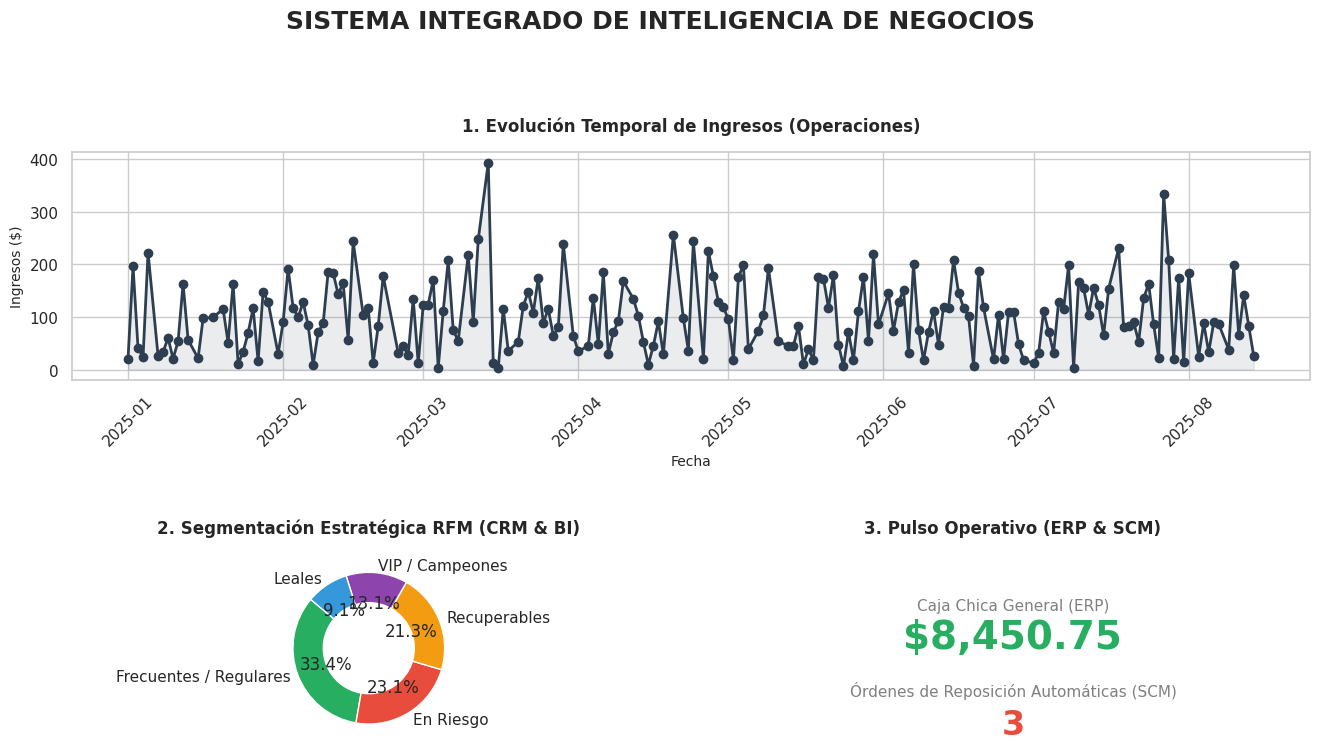

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from typing import Dict

# Configuración estética global para el Dashboard
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

class DashboardGerencial:
    """
    Capa de Vista (Front-End Analítico).
    Recibe estructuras de datos procesadas por el Core y el motor RFM para renderizar
    un tablero de control estratégico usando principios de POO en Matplotlib.
    """
    def __init__(self, df_ventas: pd.DataFrame, distribucion_rfm: pd.Series, kpis_operativos: Dict[str, float]):
        self._df_ventas = df_ventas
        self._rfm = distribucion_rfm
        self._kpis = kpis_operativos
        # Inicializamos los objetos Figure y Grid (Lienzo en blanco)
        self._fig = None

    def _procesar_serie_tiempo(self) -> pd.Series:
        """Agrupa las ventas por día para el gráfico evolutivo."""
        # Extraemos solo la fecha (sin la hora)
        self._df_ventas['Date'] = self._df_ventas['Order Time'].dt.date
        self._df_ventas['Total_Spend'] = self._df_ventas['Quantity'] * self._df_ventas['Price']
        # Agrupación transaccional: Suma de ingresos diarios
        ventas_diarias = self._df_ventas.groupby('Date')['Total_Spend'].sum()
        return ventas_diarias

    def _dibujar_evolucion_ventas(self, ax: plt.Axes) -> None:
        """Renderiza el gráfico de líneas (Series de Tiempo)."""
        ventas_diarias = self._procesar_serie_tiempo()

        # Dibujamos en el objeto 'ax' específico
        ax.plot(ventas_diarias.index, ventas_diarias.values, marker='o', linestyle='-', color='#2c3e50', linewidth=2)
        ax.fill_between(ventas_diarias.index, ventas_diarias.values, alpha=0.1, color='#34495e')

        ax.set_title("1. Evolución Temporal de Ingresos (Operaciones)", fontsize=12, fontweight='bold', pad=15)
        ax.set_ylabel("Ingresos ($)", fontsize=10)
        ax.set_xlabel("Fecha", fontsize=10)
        ax.tick_params(axis='x', rotation=45)

    def _dibujar_distribucion_rfm(self, ax: plt.Axes) -> None:
        """Renderiza un gráfico de Dona para la distribución de segmentos CRM."""
        colores = ['#27ae60', '#e74c3c', '#f39c12', '#8e44ad', '#3498db']

        # Parámetro wedgeprops crea el agujero del centro (Dona)
        ax.pie(self._rfm.values, labels=self._rfm.index, autopct='%1.1f%%',
               startangle=140, colors=colores, wedgeprops=dict(width=0.4, edgecolor='w'))

        ax.set_title("2. Segmentación Estratégica RFM (CRM & BI)", fontsize=12, fontweight='bold', pad=15)

    def _dibujar_tarjetas_kpi(self, ax: plt.Axes) -> None:
        """Dibuja indicadores numéricos estáticos (ERP y SCM) sin usar ejes cartesianos."""
        ax.axis('off') # Apagamos las líneas de la gráfica
        ax.set_title("3. Pulso Operativo (ERP & SCM)", fontsize=12, fontweight='bold', pad=15)

        # Extraemos valores del diccionario inyectado
        caja = self._kpis.get('Caja Chica', 0.0)
        ordenes = self._kpis.get('Ordenes de Compra Emitidas', 0)

        # Dibujamos texto enriquecido en coordenadas relativas (0 a 1) del panel
        # KPI 1: ERP
        ax.text(0.5, 0.7, "Caja Chica General (ERP)", fontsize=11, ha='center', color='gray')
        ax.text(0.5, 0.5, f"${caja:,.2f}", fontsize=28, ha='center', fontweight='bold', color='#27ae60')

        # KPI 2: SCM
        ax.text(0.5, 0.25, "Órdenes de Reposición Automáticas (SCM)", fontsize=11, ha='center', color='gray')
        ax.text(0.5, 0.05, f"{ordenes}", fontsize=24, ha='center', fontweight='bold', color='#e74c3c')

    def renderizar_tablero(self) -> None:
        """Orquestador visual que ensambla el grid y muestra el Dashboard."""
        print("[VIEW] Renderizando Dashboard Gerencial...")

        # Creamos una figura de 14x8 pulgadas
        self._fig = plt.figure(figsize=(14, 8))
        self._fig.suptitle("SISTEMA INTEGRADO DE INTELIGENCIA DE NEGOCIOS", fontsize=18, fontweight='bold', y=0.98)

        # GridSpec permite crear layouts asimétricos (ej. fila superior completa, fila inferior dividida)
        gs = GridSpec(2, 2, figure=self._fig, height_ratios=[1.2, 1])

        # Asignamos los objetos Axes según las coordenadas de la cuadrícula
        ax_series_tiempo = self._fig.add_subplot(gs[0, :])   # Fila 0, abarca todas las columnas
        ax_rfm = self._fig.add_subplot(gs[1, 0])             # Fila 1, columna 0
        ax_kpi = self._fig.add_subplot(gs[1, 1])             # Fila 1, columna 1

        # Llamamos a los métodos privados pasando su respectivo panel (Inyección de Axes)
        self._dibujar_evolucion_ventas(ax_series_tiempo)
        self._dibujar_distribucion_rfm(ax_rfm)
        self._dibujar_tarjetas_kpi(ax_kpi)

        # Ajuste automático de márgenes y visualización
        plt.tight_layout(pad=3.0)
        plt.show()

# ==========================================
# BLOQUE DE COMPROBAR EJECUCIÓN (TESTING)
# ==========================================
if __name__ == '__main__':
    # 1. Simulación de Ingesta (Lo que haría el CoreBusiness)
    df_crudo = pd.read_csv('restaurant_orders.csv')
    df_crudo['Order Time'] = pd.to_datetime(df_crudo['Order Time'])

    # 2. Simulación de los resultados del Motor RFM (Fase 3)
    datos_rfm_mock = pd.Series({
        'Frecuentes / Regulares': 166,
        'En Riesgo': 115,
        'Recuperables': 106,
        'VIP / Campeones': 65,
        'Leales': 45
    })

    # 3. Simulación del estado actual de los módulos satélites (Fase 2)
    kpis_actuales = {
        'Caja Chica': 8450.75, # Simulación del módulo ERP
        'Ordenes de Compra Emitidas': 3 # Simulación del módulo SCM
    }

    # 4. Instanciación y Renderizado
    dashboard = DashboardGerencial(df_ventas=df_crudo, distribucion_rfm=datos_rfm_mock, kpis_operativos=kpis_actuales)
    dashboard.renderizar_tablero()